In [167]:
# =========================================
# Predicting Hospital Treatment Costs
# =========================================

# 1. Imports
# 2. Load Dataset
# 3. Initial Inspection
# 4. Data Cleaning
# 5. Exploratory Data Analysis
# 6. Feature Engineering
# 7. Preprocessing Pipeline
# 8. Train/Test Split
# 9. Linear Regression Model
# 10. Evaluation Metrics
# 11. Feature Importance
# 12. Insights & Recommendations

In [168]:
import pandas as pd
import numpy as np

In [169]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
df = pd.read_csv('/content/drive/MyDrive/healthcare_patient_journey.csv')

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           3000 non-null   int64 
 1   age                  3000 non-null   int64 
 2   gender               3000 non-null   object
 3   chronic_condition    3000 non-null   int64 
 4   admission_type       3000 non-null   object
 5   department           3000 non-null   object
 6   wait_time_min        3000 non-null   int64 
 7   length_of_stay_days  3000 non-null   int64 
 8   procedures_count     3000 non-null   int64 
 9   medication_count     3000 non-null   int64 
 10  complications        3000 non-null   int64 
 11  discharge_status     3000 non-null   object
 12  readmitted_30d       3000 non-null   int64 
 13  total_cost_€         3000 non-null   int64 
 14  satisfaction_score   3000 non-null   int64 
dtypes: int64(11), object(4)
memory usage: 351.7+ KB


In [172]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,3000.0,1500.500000,866.169729,1.0,750.75,1500.5,2250.25,3000.0
age,3000.0,53.051333,20.704901,18.0,35.00,53.0,71.00,89.0
chronic_condition,3000.0,0.405667,0.491102,0.0,0.00,0.0,1.00,1.0
wait_time_min,3000.0,33.326333,17.111559,5.0,20.75,33.0,45.00,103.0
length_of_stay_days,3000.0,3.535000,2.024881,1.0,2.00,3.0,5.00,11.0
procedures_count,3000.0,2.435667,1.595842,0.0,1.00,2.0,3.00,10.0
medication_count,3000.0,3.404667,1.890883,0.0,2.00,3.0,5.00,11.0
complications,3000.0,0.160333,0.366976,0.0,0.00,0.0,0.00,1.0
readmitted_30d,3000.0,0.234667,0.423861,0.0,0.00,0.0,0.00,1.0
total_cost_€,3000.0,2772.040000,1086.215721,750.0,1900.00,2670.0,3490.00,6610.0


In [173]:
df.columns

Index(['patient_id', 'age', 'gender', 'chronic_condition', 'admission_type',
       'department', 'wait_time_min', 'length_of_stay_days',
       'procedures_count', 'medication_count', 'complications',
       'discharge_status', 'readmitted_30d', 'total_cost_€',
       'satisfaction_score'],
      dtype='object')

In [174]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
chronic_condition,0
admission_type,0
department,0
wait_time_min,0
length_of_stay_days,0
procedures_count,0
medication_count,0


In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

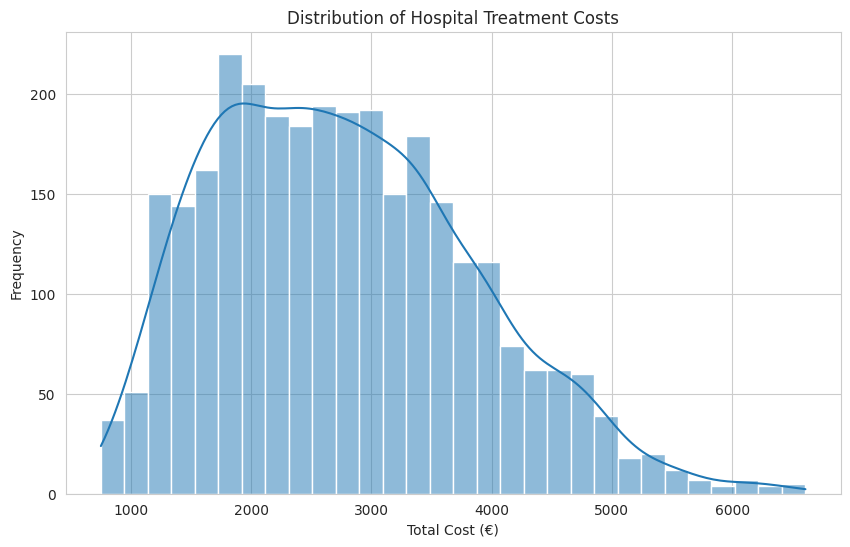

In [176]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['total_cost_€'],
    bins=30,
    kde=True
)

plt.title('Distribution of Hospital Treatment Costs')

plt.xlabel('Total Cost (€)')

plt.ylabel('Frequency')

plt.show()

In [177]:
df['total_cost_€'].describe()

,total_cost_€
count,3000.000000
mean,2772.040000
std,1086.215721
min,750.000000
25%,1900.000000
50%,2670.000000
75%,3490.000000
max,6610.000000


In [178]:
df['total_cost_€'].skew()

np.float64(0.5273749781305151)

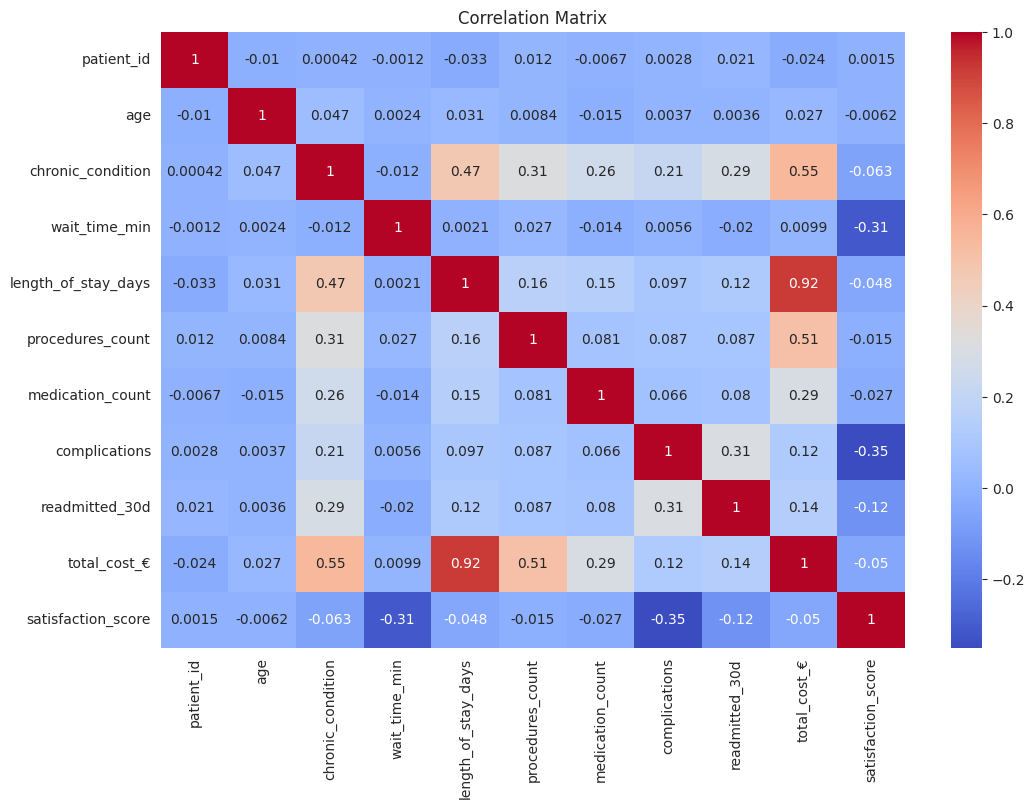

In [179]:
numeric_df = df.select_dtypes(include=['int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

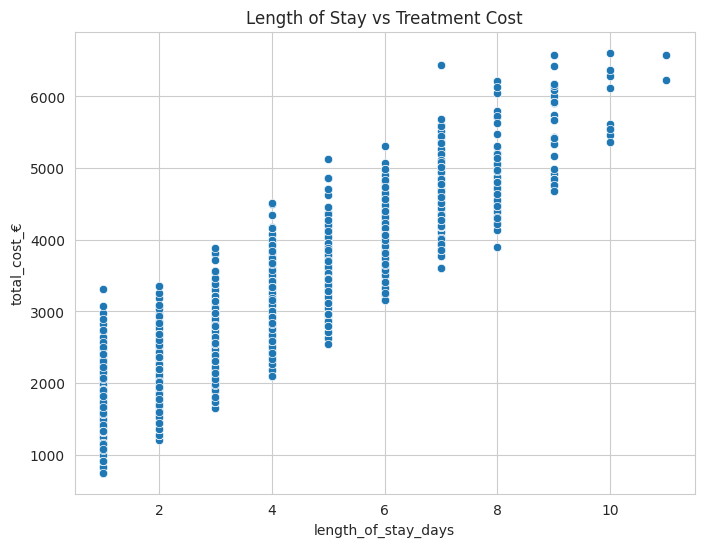

In [180]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['length_of_stay_days'],
    y=df['total_cost_€']
)

plt.title('Length of Stay vs Treatment Cost')

plt.show()

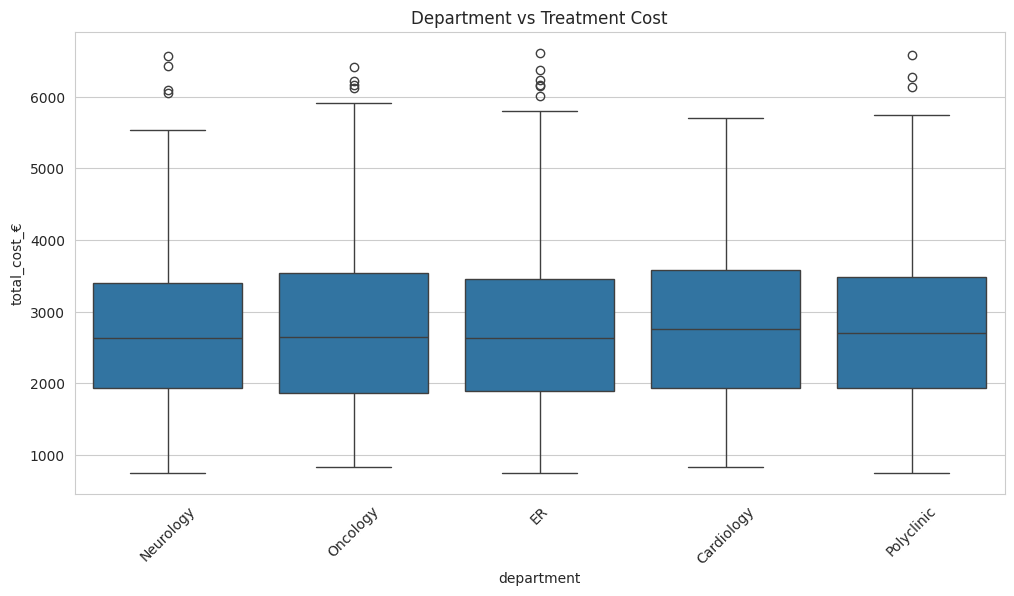

In [181]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['department'],
    y=df['total_cost_€']
)

plt.xticks(rotation=45)

plt.title('Department vs Treatment Cost')

plt.show()

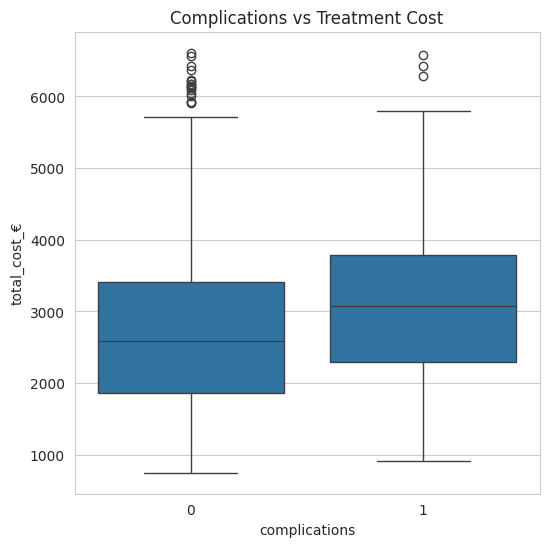

In [182]:
plt.figure(figsize=(6,6))

sns.boxplot(
    x=df['complications'],
    y=df['total_cost_€']
)

plt.title('Complications vs Treatment Cost')

plt.show()

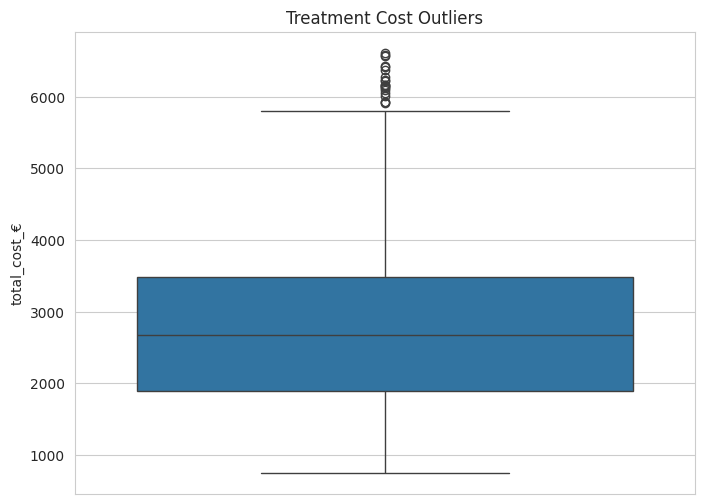

In [183]:
plt.figure(figsize=(8,6))

sns.boxplot(y=df['total_cost_€'])

plt.title('Treatment Cost Outliers')

plt.show()

In [184]:
df[['length_of_stay_days','total_cost_€']].corr()

,length_of_stay_days,total_cost_€
length_of_stay_days,1.00000,0.91854
total_cost_€,0.91854,1.00000


In [185]:
df.corr(numeric_only=True)['total_cost_€'].sort_values(ascending=False)

,total_cost_€
total_cost_€,1.000000
length_of_stay_days,0.918540
chronic_condition,0.548256
procedures_count,0.513653
medication_count,0.292974
readmitted_30d,0.140557
complications,0.122631
age,0.026661
wait_time_min,0.009884
patient_id,-0.024091


In [186]:
df = df.drop('patient_id', axis=1)

In [187]:
X = df.drop('total_cost_€', axis=1)
y = df['total_cost_€']

In [188]:
X = pd.get_dummies(X, drop_first=True)

In [189]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [190]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [191]:
y_pred = model.predict(X_test)


In [192]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 5.951028132390582e-23
Mean Absolute Error: 6.3909055825206455e-12
R-squared: 1.0
Root Mean Squared Error: 7.714290720727721e-12


In [193]:
df.columns

Index(['age', 'gender', 'chronic_condition', 'admission_type', 'department',
       'wait_time_min', 'length_of_stay_days', 'procedures_count',
       'medication_count', 'complications', 'discharge_status',
       'readmitted_30d', 'total_cost_€', 'satisfaction_score'],
      dtype='object')

In [194]:
'total_cost_€' in X.columns

False

In [195]:
df.corr(numeric_only=True)['total_cost_€'].sort_values(ascending=False)

,total_cost_€
total_cost_€,1.000000
length_of_stay_days,0.918540
chronic_condition,0.548256
procedures_count,0.513653
medication_count,0.292974
readmitted_30d,0.140557
complications,0.122631
age,0.026661
wait_time_min,0.009884
satisfaction_score,-0.049916


In [196]:
X.columns.tolist()

['age',
 'chronic_condition',
 'wait_time_min',
 'length_of_stay_days',
 'procedures_count',
 'medication_count',
 'complications',
 'readmitted_30d',
 'satisfaction_score',
 'gender_male',
 'admission_type_scheduled',
 'department_ER',
 'department_Neurology',
 'department_Oncology',
 'department_Polyclinic',
 'discharge_status_referred']

<Axes: >

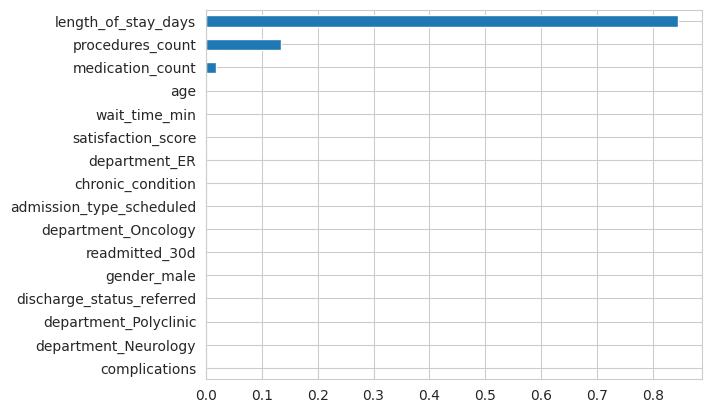

In [197]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

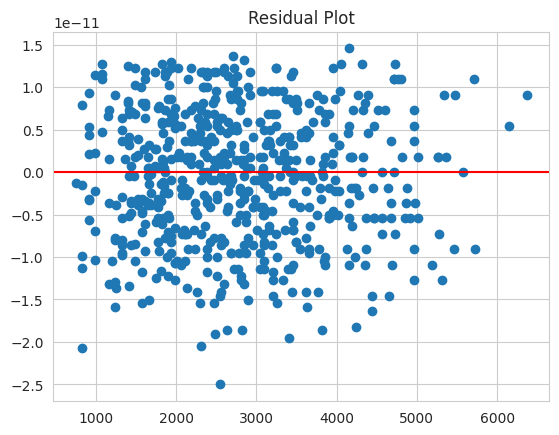

In [198]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

In [199]:
df_backup = df.copy()

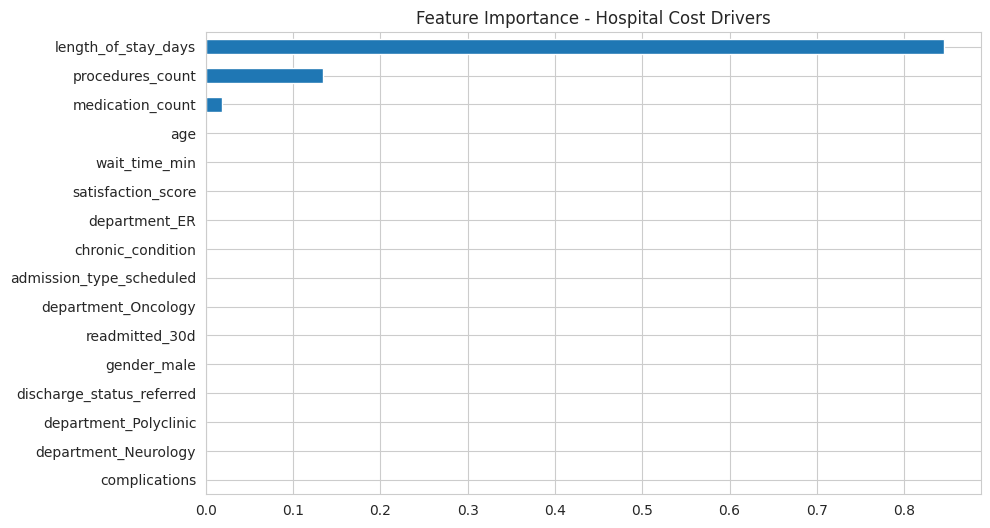

In [200]:
from sklearn.ensemble import RandomForestRegressor

# model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

# sort
importance = importance.sort_values()

# plot
plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Feature Importance - Hospital Cost Drivers")
plt.show()